<a href="https://colab.research.google.com/github/DiptaDas07/CSE475/blob/main/Lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE

**Download datasets**

In [23]:
!pip -q install gdown

import gdown

gdown.download(id="1nLdjq_y0hJ4_A-kH6MZb9x-GDk4sNrRY", output="adult.csv", quiet=False)
gdown.download(id="1cO2SQHvkg1SWUJgk4FU_mVx_l_NSnrn8", output="processed_data_adults.csv", quiet=False)
gdown.download(id="1Q6pdhzWFu2oegWMPvrOE8dWTra8FJsTf", output="Mall_Customers.csv", quiet=False)

print("Downloaded:", "! adult.csv, ! processed_data_adults.csv, ! Mall_Customers.csv")

Downloading...
From: https://drive.google.com/uc?id=1nLdjq_y0hJ4_A-kH6MZb9x-GDk4sNrRY
To: /content/adult.csv
100%|██████████| 4.10M/4.10M [00:00<00:00, 16.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1cO2SQHvkg1SWUJgk4FU_mVx_l_NSnrn8
To: /content/processed_data_adults.csv
100%|██████████| 16.2M/16.2M [00:00<00:00, 95.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Q6pdhzWFu2oegWMPvrOE8dWTra8FJsTf
To: /content/Mall_Customers.csv
100%|██████████| 3.98k/3.98k [00:00<00:00, 11.3MB/s]

Downloaded: ! adult.csv, ! processed_data_adults.csv, ! Mall_Customers.csv


**Adult Dataset (Preprocess + Clustering + Evaluation + PCA/t-SNE)**

In [24]:
df = pd.read_csv("adult.csv")
print("Raw shape:", df.shape)
df.head()

Raw shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


**Clean + Encode + Scale (adult.csv → processed_data.csv)**

In [25]:
df = df.replace(" ?", pd.NA).dropna().copy()

df_unsup = df.drop(columns=["income"])

categorical_cols = df_unsup.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df_unsup.select_dtypes(include=["int64", "float64"]).columns.tolist()

scaler = StandardScaler()
X_num = scaler.fit_transform(df_unsup[numerical_cols])

encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
X_cat = encoder.fit_transform(df_unsup[categorical_cols])

X = np.hstack([X_num, X_cat])
final_cols = numerical_cols + encoder.get_feature_names_out(categorical_cols).tolist()

processed_df_from_raw = pd.DataFrame(X, columns=final_cols)
processed_df_from_raw.to_csv("processed_data.csv", index=False)

print("Processed shape:", processed_df_from_raw.shape)
processed_df_from_raw.head()

Processed shape: (32561, 100)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,3.769612,-1.067997,-0.420060,-0.14592,10.593507,-0.035429,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3.183112,-0.539169,-0.420060,-0.14592,10.593507,-1.817204,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.010110,-0.035220,-0.031360,-0.14592,10.593507,-0.035429,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.130359,-0.468215,-2.363558,-0.14592,9.461864,-0.035429,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.177296,0.709482,-0.031360,-0.14592,9.461864,-0.035429,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Load processed_data_adults.csv**

In [26]:
processed_data_df = pd.read_csv("processed_data_adults.csv")
print("Processed(adults) shape:", processed_data_df.shape)
processed_data_df.head()

Processed(adults) shape: (32561, 100)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,3.769612,-1.067997,-0.420060,-0.14592,10.593507,-0.035429,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3.183112,-0.539169,-0.420060,-0.14592,10.593507,-1.817204,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.010110,-0.035220,-0.031360,-0.14592,10.593507,-0.035429,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.130359,-0.468215,-2.363558,-0.14592,9.461864,-0.035429,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.177296,0.709482,-0.031360,-0.14592,9.461864,-0.035429,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Elbow method**

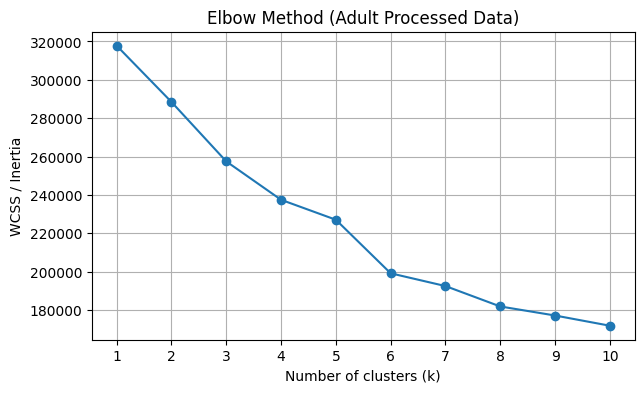

In [27]:
X_adult = processed_data_df.values

wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_adult)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(K_range), wcss, marker="o")
plt.title("Elbow Method (Adult Processed Data)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

**Run KMeans + DBSCAN**

In [28]:

k = 8
kmeans = KMeans(n_clusters=k, random_state=42, max_iter=30, n_init="auto")
processed_data_df["KMeans_Cluster"] = kmeans.fit_predict(X_adult)

dbscan = DBSCAN(eps=0.5, min_samples=5)
processed_data_df["DBSCAN_Cluster"] = dbscan.fit_predict(X_adult)

print("KMeans clusters:", processed_data_df["KMeans_Cluster"].nunique())
print("DBSCAN labels:", processed_data_df["DBSCAN_Cluster"].nunique(), "(includes -1 noise if present)")
processed_data_df[["KMeans_Cluster","DBSCAN_Cluster"]].head()

KMeans clusters: 8
DBSCAN labels: 287 (includes -1 noise if present)


,KMeans_Cluster,DBSCAN_Cluster
0,6,-1
1,6,-1
2,6,-1
3,6,-1
4,6,-1


**Evaluation (Silhouette + Davies–Bouldin)**

In [29]:
def safe_silhouette(X, labels):
    uniq = set(labels)
    if len(uniq) < 2:
        return None
    if -1 in uniq:
        mask = labels != -1
        if len(set(labels[mask])) < 2:
            return None
        return silhouette_score(X[mask], labels[mask])
    return silhouette_score(X, labels)

def safe_dbi(X, labels):
    uniq = set(labels)
    if len(uniq) < 2:
        return None
    if -1 in uniq:
        mask = labels != -1
        if len(set(labels[mask])) < 2:
            return None
        return davies_bouldin_score(X[mask], labels[mask])
    return davies_bouldin_score(X, labels)

X = X_adult
km_labels = processed_data_df["KMeans_Cluster"].values
db_labels = processed_data_df["DBSCAN_Cluster"].values

km_sil = safe_silhouette(X, km_labels)
db_sil = safe_silhouette(X, db_labels)

km_dbi = safe_dbi(X, km_labels)
db_dbi = safe_dbi(X, db_labels)

print("KMeans Silhouette:", km_sil)
print("DBSCAN Silhouette:", db_sil)
print("KMeans Davies–Bouldin:", km_dbi)
print("DBSCAN Davies–Bouldin:", db_dbi)

KMeans Silhouette: 0.11291068593154656
DBSCAN Silhouette: 0.25620645444020956
KMeans Davies–Bouldin: 1.7971096790402077
DBSCAN Davies–Bouldin: 0.875919716305451


**PCA 2D Visualization (KMeans vs DBSCAN)**

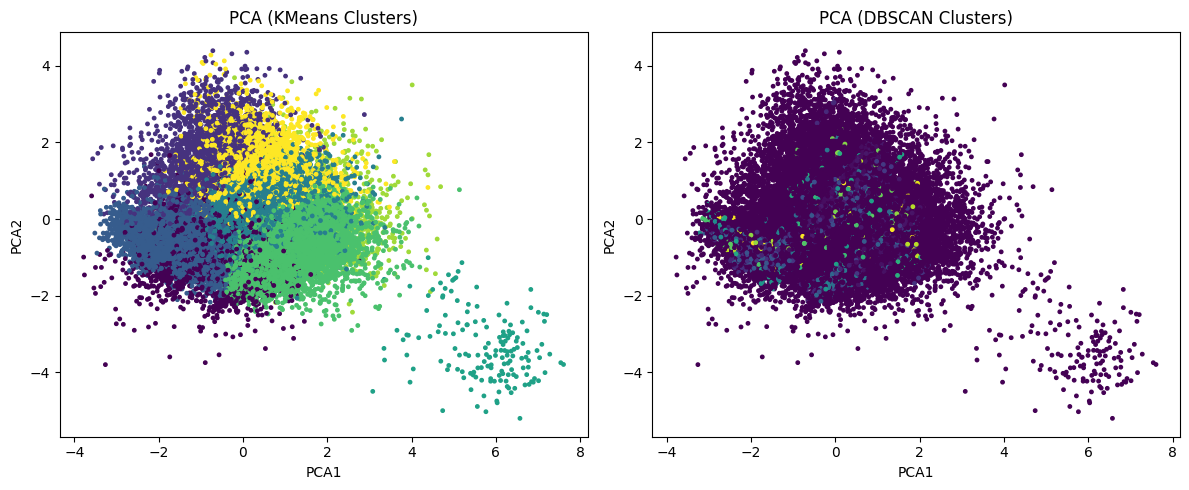

In [30]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_adult)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=processed_data_df["KMeans_Cluster"], s=6)
plt.title("PCA (KMeans Clusters)")
plt.xlabel("PCA1"); plt.ylabel("PCA2")

plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=processed_data_df["DBSCAN_Cluster"], s=6)
plt.title("PCA (DBSCAN Clusters)")
plt.xlabel("PCA1"); plt.ylabel("PCA2")

plt.tight_layout()
plt.show()

**GMM (Gaussian Mixture Model) + Evaluation + PCA plot**

GMM Silhouette: 0.07181924358049632
GMM Davies–Bouldin: 3.465243116564267


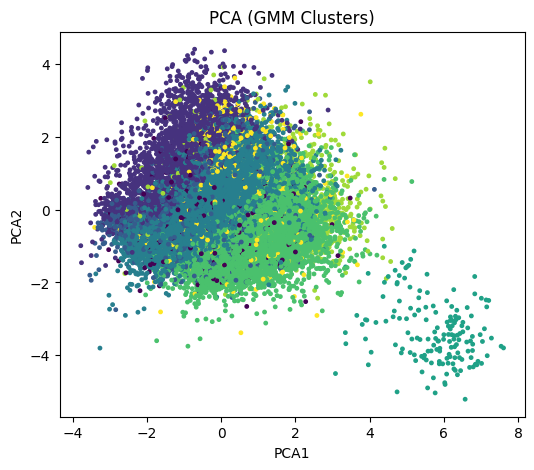

In [31]:
gmm = GaussianMixture(n_components=8, random_state=42)
gmm_labels = gmm.fit_predict(X_adult)
processed_data_df["GMM_Cluster"] = gmm_labels

gmm_sil = safe_silhouette(X_adult, gmm_labels)
gmm_dbi = safe_dbi(X_adult, gmm_labels)

print("GMM Silhouette:", gmm_sil)
print("GMM Davies–Bouldin:", gmm_dbi)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=processed_data_df["GMM_Cluster"], s=6)
plt.title("PCA (GMM Clusters)")
plt.xlabel("PCA1"); plt.ylabel("PCA2")
plt.show()

**t-SNE Visualization (Heavy / slow)**

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


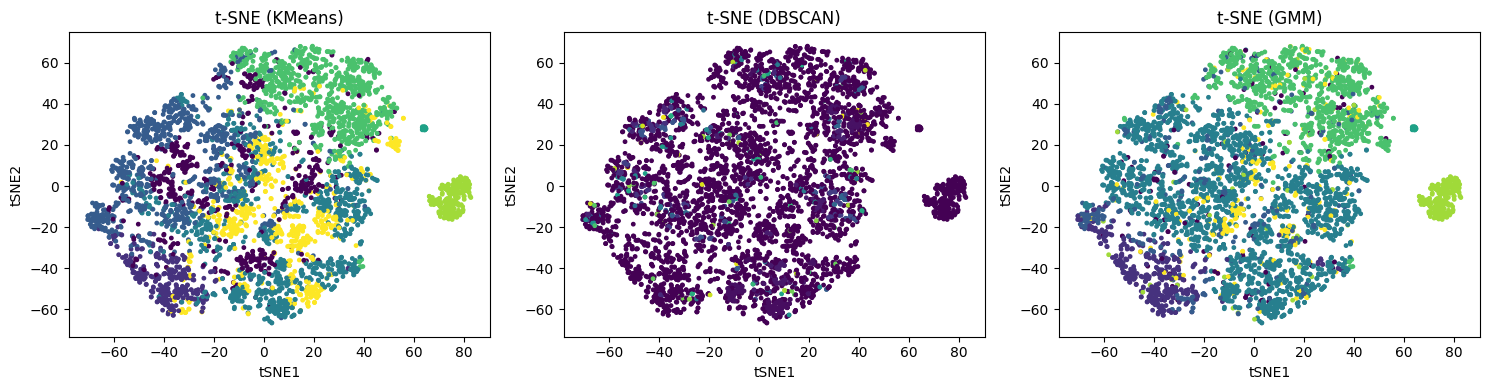

In [32]:
sample_n = 5000
if X_adult.shape[0] > sample_n:
    idx = np.random.RandomState(42).choice(X_adult.shape[0], sample_n, replace=False)
    X_tsne_in = X_adult[idx]
    km_l = km_labels[idx]
    db_l = db_labels[idx]
    gmm_l = gmm_labels[idx]
else:
    X_tsne_in = X_adult
    km_l = km_labels
    db_l = db_labels
    gmm_l = gmm_labels

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate="auto", init="pca")
X_tsne = tsne.fit_transform(X_tsne_in)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=km_l, s=6)
plt.title("t-SNE (KMeans)"); plt.xlabel("tSNE1"); plt.ylabel("tSNE2")

plt.subplot(1,3,2)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=db_l, s=6)
plt.title("t-SNE (DBSCAN)"); plt.xlabel("tSNE1"); plt.ylabel("tSNE2")

plt.subplot(1,3,3)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=gmm_l, s=6)
plt.title("t-SNE (GMM)"); plt.xlabel("tSNE1"); plt.ylabel("tSNE2")

plt.tight_layout()
plt.show()

**Load Mall_Customers.csv**

In [33]:
mall = pd.read_csv("Mall_Customers.csv")
mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Preprocess Mall data**

In [34]:
mall2 = mall.drop(columns=["CustomerID"]).copy()

# one-hot for Gender
mall2 = pd.get_dummies(mall2, columns=["Gender"], drop_first=True)

scaler = StandardScaler()
X_mall = scaler.fit_transform(mall2)

print("Mall processed shape:", X_mall.shape)

Mall processed shape: (200, 4)


**Elbow (Mall) + Run KMeans/DBSCAN/GMM**

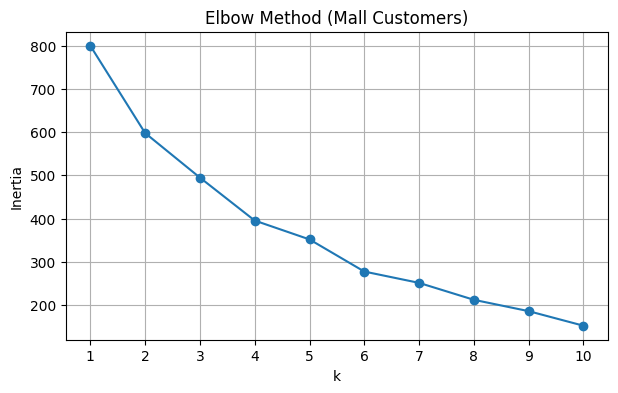

Mall KMeans clusters: 5
Mall DBSCAN labels: 10
Mall GMM clusters: 5


In [35]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_mall)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method (Mall Customers)")
plt.xlabel("k"); plt.ylabel("Inertia")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

k = 5
mall_km = KMeans(n_clusters=k, random_state=42, n_init="auto")
mall_km_labels = mall_km.fit_predict(X_mall)

mall_db = DBSCAN(eps=0.6, min_samples=5)
mall_db_labels = mall_db.fit_predict(X_mall)

mall_gmm = GaussianMixture(n_components=k, random_state=42)
mall_gmm_labels = mall_gmm.fit_predict(X_mall)

print("Mall KMeans clusters:", len(set(mall_km_labels)))
print("Mall DBSCAN labels:", len(set(mall_db_labels)))
print("Mall GMM clusters:", len(set(mall_gmm_labels)))

**Mall Evaluation + PCA Visualization**

Mall KMeans | Silhouette: 0.2719102346618833 | Davies–Bouldin: 1.181091452406171
Mall DBSCAN | Silhouette: 0.34073658147267427 | Davies–Bouldin: 0.8608292819374457
Mall GMM | Silhouette: 0.22164014854021985 | Davies–Bouldin: 1.210613767104373


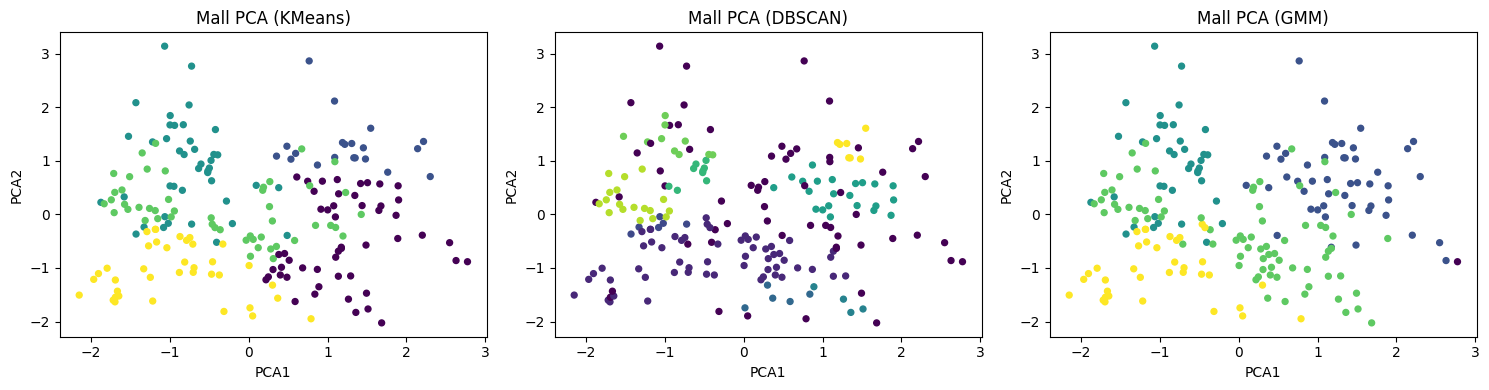

In [36]:
def eval_print(X, labels, name):
    sil = safe_silhouette(X, labels)
    dbi = safe_dbi(X, labels)
    print(f"{name} | Silhouette: {sil} | Davies–Bouldin: {dbi}")

eval_print(X_mall, mall_km_labels, "Mall KMeans")
eval_print(X_mall, mall_db_labels, "Mall DBSCAN")
eval_print(X_mall, mall_gmm_labels, "Mall GMM")

pca = PCA(n_components=2, random_state=42)
X_mall_pca = pca.fit_transform(X_mall)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(X_mall_pca[:,0], X_mall_pca[:,1], c=mall_km_labels, s=18)
plt.title("Mall PCA (KMeans)"); plt.xlabel("PCA1"); plt.ylabel("PCA2")

plt.subplot(1,3,2)
plt.scatter(X_mall_pca[:,0], X_mall_pca[:,1], c=mall_db_labels, s=18)
plt.title("Mall PCA (DBSCAN)"); plt.xlabel("PCA1"); plt.ylabel("PCA2")

plt.subplot(1,3,3)
plt.scatter(X_mall_pca[:,0], X_mall_pca[:,1], c=mall_gmm_labels, s=18)
plt.title("Mall PCA (GMM)"); plt.xlabel("PCA1"); plt.ylabel("PCA2")

plt.tight_layout()
plt.show()